# Bitcoin Price Prediction with TimesFM 3.0 (1-Minute Intervals)

This notebook demonstrates how to use the Google TimesFM 3.0 model to forecast Bitcoin prices on a **1-minute granularity**. We will use the most recent 120 minutes of price data as context to predict the next 30 minutes, and evaluate the model by comparing the predictions to the actual ground truth.

## 1. Import Libraries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from timesfm3.torch import TimesFM3Forecaster

import warnings
warnings.filterwarnings("ignore")

/home/dskim/fork/timesfm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Fetch Bitcoin Data (1m Interval)

Note: Yahoo Finance API allows a maximum of 7 days for 1-minute granularity data. We will fetch the last 7 days and extract the final 150 minutes (120 min for context, 30 min for ground truth evaluation).

In [2]:
ticker = "BTC-USD"
data = yf.download(ticker, period="7d", interval="1m")

# Handle potential MultiIndex columns from newer yfinance versions
if isinstance(data.columns, pd.MultiIndex):
    close_prices = data['Close'][ticker].values
    dates = data.index
else:
    close_prices = data['Close'].values
    dates = data.index

# Set up the evaluation slice
eval_len = 150
horizon_len = 30
context_len = eval_len - horizon_len

recent_prices = close_prices[-eval_len:].astype(np.float32)
recent_dates = dates[-eval_len:]

# Split into context (past) and ground truth (future to predict)
context = recent_prices[:context_len]
ground_truth = recent_prices[context_len:]
context_dates = recent_dates[:context_len]
gt_dates = recent_dates[context_len:]

print(f"Fetched total data points: {len(close_prices)}")
print(f"Context length: {len(context)} minutes")
print(f"Ground truth length: {len(ground_truth)} minutes")

[*********************100%***********************]  1 of 1 completed

Fetched total data points: 9459
Context length: 120 minutes
Ground truth length: 30 minutes


## 3. Load TimesFM 3.0 Model
We use `device="cpu"` to ensure maximum compatibility.

In [3]:
forecaster = TimesFM3Forecaster.from_pretrained(
    "google/timesfm-3.0-pytorch",
    per_core_batch_size=4,
    device="cpu"
)
print(f"TimesFM3 loaded on device: {forecaster.device}")

TimesFM3 loaded on device: cpu


## 4. Run Zero-Shot Inference
We provide the context to the forecaster and set `horizon=30` to predict the next 30 minutes.

In [4]:
torch_out = forecaster.predict(
    context=context,
    horizon=horizon_len,
    return_quantiles=True,
)

print("Forecast generated successfully!")
print(f"Point forecast shape: {torch_out.forecast.shape}")

# Calculate Error (MAE)
mae = np.mean(np.abs(torch_out.forecast - ground_truth))
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Forecast generated successfully!
Point forecast shape: (30,)
Mean Absolute Error (MAE): 34.12


## 5. Visualize Results
Plot the 120-minute context alongside the actual 30-minute ground truth and the model's forecast.

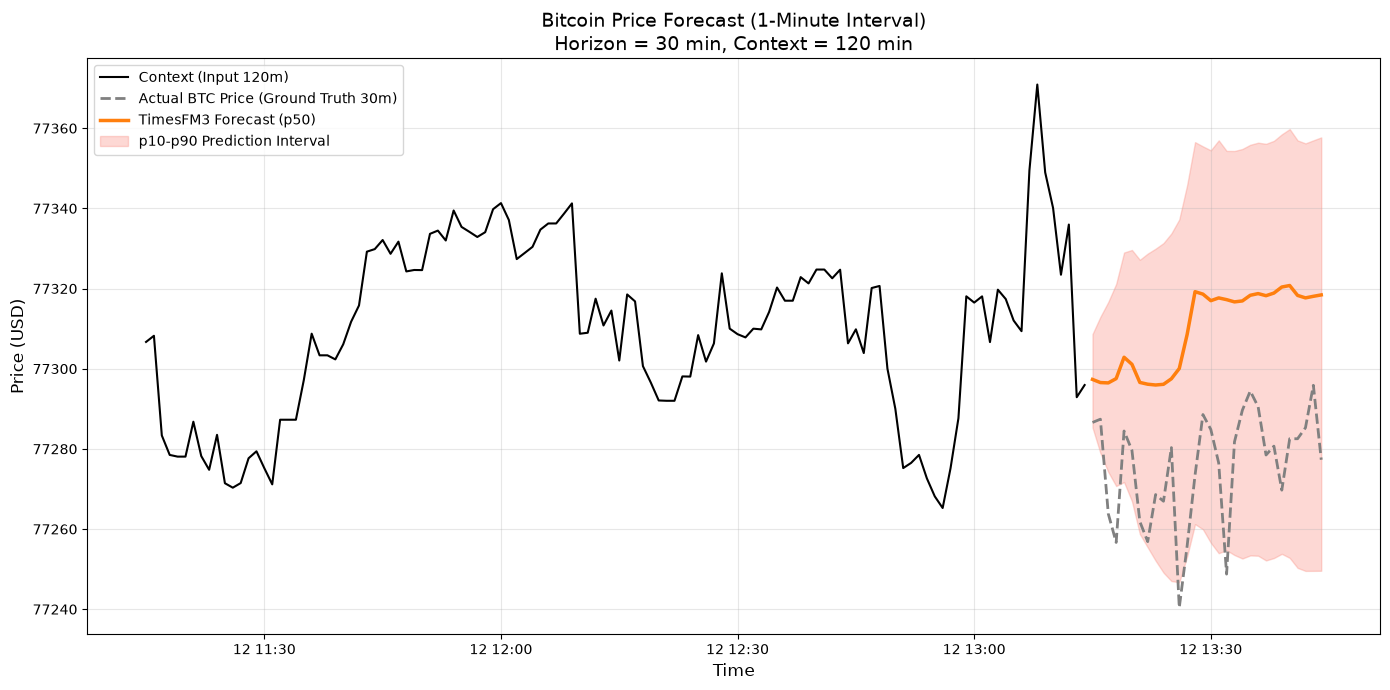

In [5]:
plt.figure(figsize=(14, 7))

# Plot the 120 minutes of context
plt.plot(context_dates, context, label="Context (Input 120m)", color="black", linewidth=1.5)

# Plot the 30 minutes of actual ground truth
plt.plot(gt_dates, ground_truth, label="Actual BTC Price (Ground Truth 30m)", color="gray", linestyle="--", linewidth=2.0)

# Plot the forecast median (point forecast)
plt.plot(gt_dates, torch_out.forecast, label="TimesFM3 Forecast (p50)", color="#ff7f0e", linewidth=2.5)

# Plot uncertainty intervals
if torch_out.quantiles is not None:
    plt.fill_between(
        gt_dates,
        torch_out.quantiles[:, 0],   # usually p10
        torch_out.quantiles[:, -1],  # usually p90
        color="salmon",
        alpha=0.3,
        label="p10-p90 Prediction Interval",
    )

plt.title(f"Bitcoin Price Forecast (1-Minute Interval)\nHorizon = {horizon_len} min, Context = {context_len} min", fontsize=14)
plt.ylabel("Price (USD)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()